# TP Module 2 — Transfer Learning & Fine-tuning sur lésions cutanées (DermaMNIST)

**Formation avancée en Deep Learning avec PyTorch — Computer Vision & Séries temporelles**

*Bassem Ben Hamed — ENETCOM, Université de Sfax*

---

## Objectifs du TP

Après ce TP, vous serez capable de :

1. **Charger un modèle pré-entraîné** ImageNet via `torchvision.models`
2. Distinguer **feature extraction** et **fine-tuning** et choisir selon la situation
3. Mettre en œuvre un **learning rate différentiel** entre backbone et tête
4. Utiliser le scheduler **OneCycleLR** (warm-up + annealing)
5. Comparer **3 stratégies** sur le même dataset : feature extraction, fine-tuning du dernier bloc, fine-tuning complet
6. Diagnostiquer **catastrophic forgetting** et autres pièges du transfer learning
7. Évaluer en termes d'**accuracy**, **macro-F1** (dataset déséquilibré), **temps d'entraînement** et **nombre de paramètres apprenables**

## Pré-requis

- Les TP 1 à 3 du Module 1 (en particulier le TP 3 sur CNN qui utilise le même dataset **DermaMNIST**)
- `torch`, `torchvision`, `medmnist`, `matplotlib`, `numpy`

## Dataset

On réutilise **DermaMNIST** (MedMNIST / HAM10000, lésions cutanées RGB, 7 classes) du TP 3. Cela permet de comparer **directement** le CNN `SmallVGG` entraîné from scratch (TP 3) avec un modèle pré-entraîné ImageNet. C'est aussi un cas où le **domaine cible est éloigné d'ImageNet** (imagerie médicale, fortement déséquilibrée) : idéal pour observer *quand* le fine-tuning profond surpasse nettement la simple feature extraction.

## Partie I — Rappels théoriques

### I.1 Le problème du transfer learning

Soit un modèle **source** $f_{\theta_S}$ entraîné sur un dataset source $(\mathcal{X}_S, \mathcal{Y}_S) \sim \mathcal{D}_S$ (typiquement ImageNet : 1.28 M images, 1000 classes). On dispose d'un dataset **cible** $(\mathcal{X}_T, \mathcal{Y}_T) \sim \mathcal{D}_T$ avec $|\mathcal{D}_T| \ll |\mathcal{D}_S|$ (quelques milliers d'exemples).

L'objectif est de trouver $\theta_T$ qui minimise le risque empirique sur $\mathcal{D}_T$ :

$$
\theta_T \;=\; \arg\min_{\theta}\; \mathbb{E}_{(x, y) \sim \mathcal{D}_T}\bigl[\mathcal{L}(f_\theta(x), y)\bigr],
\qquad \text{initialisation : } \theta_{\text{init}} = \theta_S.
$$

**L'initialisation par $\theta_S$** apporte un avantage majeur :
- Les **features bas niveau** (arêtes, textures, formes simples) sont **universelles** en vision et ne nécessitent pas d'être ré-apprises.
- Le réseau commence l'optimisation dans un **bassin d'attraction favorable**, loin de l'initialisation aléatoire qui partirait souvent dans une mauvaise région du paysage de perte.

**Quand est-ce pertinent ?**
- Peu de données ($10^2$ à $10^4$ images)
- Domaine proche d'ImageNet (photos naturelles, objets quotidiens)
- Budget GPU limité (entraînement $\times 10$ à $\times 100$ plus rapide qu'un from-scratch équivalent)

### I.2 Deux stratégies : feature extraction vs fine-tuning

Décomposons le modèle pré-entraîné en deux parties :
$$
f_\theta(x) \;=\; h_{\theta_h}\bigl(g_{\theta_g}(x)\bigr)
$$
où $g_{\theta_g}$ est le **backbone** (couches convolutives) et $h_{\theta_h}$ la **tête** (classifieur final).

#### Stratégie A — Feature Extraction ("figer" le backbone)

$$
\theta_g \text{ figé} \;\Rightarrow\; \nabla_{\theta_g} \mathcal{L} = 0,
\qquad \text{on n'optimise que } \theta_h.
$$

En PyTorch :
```python
for param in model.parameters():
    param.requires_grad = False     # gel total
model.fc = nn.Linear(2048, num_classes)   # tête neuve (requires_grad=True par défaut)
```

**Quand l'utiliser ?**
- Très peu de données ($10^2$–$10^3$)
- Domaine proche d'ImageNet
- GPU faible ou pas de GPU du tout

#### Stratégie B — Fine-Tuning complet

Tous les paramètres sont mis à jour, mais avec un **learning rate différentiel** : très petit pour le backbone (préserver les features pré-entraînées), plus grand pour la tête (apprendre la nouvelle tâche).

$$
\theta_g \leftarrow \theta_g - \eta_g \nabla_{\theta_g} \mathcal{L}, \quad \eta_g \sim 10^{-5} \\
\theta_h \leftarrow \theta_h - \eta_h \nabla_{\theta_h} \mathcal{L}, \quad \eta_h \sim 10^{-3}
$$

**Quand l'utiliser ?**
- Dataset de taille moyenne ($10^4$–$10^5$)
- Domaine éloigné d'ImageNet (médical, satellite)
- GPU disponible (entraînement plus long)

### I.3 Learning rate différentiel — pourquoi ?

Les premières couches du backbone détectent des **features bas niveau** (bords, textures) qui sont **universelles** : un grand learning rate les détruirait inutilement. Les dernières couches détectent des features de haut niveau **spécifiques** aux objets d'ImageNet (silhouettes d'animaux, de véhicules…) qu'il faut **réadapter** à la nouvelle tâche.

D'où la règle empirique : **lr_backbone ≈ lr_tête / 100**.

En PyTorch on définit plusieurs *parameter groups* :

```python
optimizer = torch.optim.Adam([
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
], weight_decay=1e-4)
```

Variante plus simple : **layer-wise lr decay** $\eta_\ell = \eta_{\max} \cdot \gamma^{L-\ell}$ (couches plus profondes = lr plus grand).

### I.4 OneCycleLR — warm-up + annealing

Le scheduler **OneCycleLR** (Smith, 2018) effectue un seul cycle complet sur la durée totale d'entraînement :

$$
\eta_t = \begin{cases}
\eta_{\min} + (\eta_{\max} - \eta_{\min}) \cdot \dfrac{t}{T_w} & \text{si } t \le T_w \quad \text{(warm-up linéaire)} \\[8pt]
\eta_{\min} + (\eta_{\max} - \eta_{\min}) \cdot \dfrac{1 + \cos\!\bigl(\pi \cdot \frac{t - T_w}{T - T_w}\bigr)}{2} & \text{si } t > T_w \quad \text{(annealing cosinus)}
\end{cases}
$$

Avec $T_w \approx 0.3\,T$ (warm-up sur 30 % des steps).

**Pourquoi ça marche ?**
- Le **warm-up** stabilise BatchNorm et les moments d'Adam au démarrage (pas d'à-coup brutal)
- Le **pic** $\eta_{\max}$ permet d'explorer rapidement le paysage de perte
- L'**annealing** affine la convergence vers le minimum

**En fine-tuning**, $\eta_{\max}$ est typiquement 10× plus grand que ce qu'on utiliserait sans scheduler. PyTorch : `torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=..., total_steps=...)`.

### I.5 Pièges du transfer learning

| Piège | Symptôme | Remède |
|-------|----------|--------|
| Mauvaise normalisation | Acc bloquée près du hasard | Utiliser les **stats ImageNet** : $\mu{=}(0.485, 0.456, 0.406)$, $\sigma{=}(0.229, 0.224, 0.225)$ |
| BatchNorm en mode `train()` pendant le fine-tuning | Statistiques running corrompues | Passer BN en `eval()` ou utiliser un batch suffisamment grand |
| Learning rate trop grand sur le backbone | **Catastrophic forgetting** : les features pré-entraînées sont écrasées | Réduire `lr_backbone`, ou geler les premières couches |
| Tête initialisée mal | Loss qui diverge en début d'entraînement | Initialiser explicitement la nouvelle `Linear` (Kaiming ou Xavier) |
| Tête trop grande sur dataset minuscule | Overfit immédiat | Tête plus simple, dropout, augmentation |
| Forget freezing | Tous les paramètres mis à jour alors qu'on voulait feature extraction | Vérifier `count_params(only_trainable=True)` avant l'entraînement |

## Partie II — Données

On reprend le même dataset que le TP 3 (**DermaMNIST**, 7 classes) et le **même module d'augmentation**, en gardant les splits officiels train/val/test de MedMNIST. On demande la résolution **128×128** (`size=128` ; valeurs MedMNIST possibles : 28/64/128/224) : plus proche de la taille native des modèles ImageNet que les 28×28 d'origine, tout en restant rapide à entraîner.

In [1]:
import os
import time
from copy import deepcopy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import models
from torchvision.models import ResNet18_Weights
from torchvision.transforms import v2 as T
from medmnist import DermaMNIST, INFO

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# On réutilise le dossier de données du TP 3 (../module_1/data) où DermaMNIST
# a déjà pu être téléchargé ; sinon on retombe sur un dossier local.
DATA_DIR = Path("../module_1/data")
if not DATA_DIR.exists():
    DATA_DIR = Path("./data")
DATA_DIR.mkdir(exist_ok=True, parents=True)
CKPT_DIR = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)

IMG_SIZE = 128
BATCH    = 64
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

info          = INFO["dermamnist"]
NUM_CLASSES   = len(info["label"])                                  # 7
CLASSES       = [info["label"][str(i)] for i in range(NUM_CLASSES)] # noms longs
CLASSES_SHORT = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
print(f"Classes ({NUM_CLASSES}) : {CLASSES_SHORT}")

PyTorch : 2.10.0
Device  : cpu
Classes (7) : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [2]:
def make_derma(split, transform=None, target_transform=None):
    """Charge un split DermaMNIST en demandant size=IMG_SIZE (RGB natif),
    avec repli sur 28×28 si la version de medmnist ne connaît pas `size`."""
    kwargs = dict(split=split, root=DATA_DIR, download=True,
                  transform=transform, target_transform=target_transform)
    try:
        return DermaMNIST(size=IMG_SIZE, **kwargs)
    except TypeError:
        return DermaMNIST(**kwargs)            # medmnist < 3.0 : images 28×28

# L'étiquette MedMNIST est un tableau (1,) -> on la ramène à un entier scalaire
squeeze_target = lambda t: int(np.asarray(t).reshape(-1)[0])

class DermaAugmenter:
    """Module d'augmentation (repris du TP 3, adapté à la dermatoscopie)."""
    def __init__(self, img_size=128):
        self.img_size = img_size
        self.train = T.Compose([
            T.RandomResizedCrop(size=img_size, scale=(0.7, 1.0), antialias=True),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),                 # pas d'orientation canonique
            T.RandomRotation(degrees=180),               # angle dermatoscopique arbitraire
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # couleur diagnostique -> modéré
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
        self.eval = T.Compose([
            T.Resize(int(img_size * 1.14), antialias=True),
            T.CenterCrop(img_size),
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    def denormalize(self, tensor):
        m = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        s = torch.tensor(IMAGENET_STD).view(3, 1, 1)
        return (tensor.cpu() * s + m).clamp(0, 1)

aug = DermaAugmenter(img_size=IMG_SIZE)

# Splits officiels MedMNIST (pas de random_split maison)
train_set = make_derma("train", transform=aug.train, target_transform=squeeze_target)
val_set   = make_derma("val",   transform=aug.eval,  target_transform=squeeze_target)
test_set  = make_derma("test",  transform=aug.eval,  target_transform=squeeze_target)

PIN = device.type == "cuda"
train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,  num_workers=0, pin_memory=PIN)
val_loader   = DataLoader(val_set,   batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=PIN)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=PIN)

# Poids de classes = inverse de la fréquence, pour compenser le fort déséquilibre
train_labels  = np.asarray(train_set.labels).reshape(-1)
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES).astype(np.float32)
class_weights = torch.tensor(class_counts.sum() / (NUM_CLASSES * class_counts),
                             dtype=torch.float32, device=device)

print(f"Train : {len(train_set):>5} | Val : {len(val_set):>5} | Test : {len(test_set):>5}")
x_batch, y_batch = next(iter(train_loader))
print(f"Batch : {x_batch.shape} | labels : {y_batch.shape} | range : [{x_batch.min():.2f}, {x_batch.max():.2f}]")
print("Poids de classes :", {CLASSES_SHORT[i]: round(float(w), 2) for i, w in enumerate(class_weights)})

Train :  7007 | Val :  1003 | Test :  2005
Batch : torch.Size([64, 3, 128, 128]) | labels : torch.Size([64]) | range : [-2.12, 2.62]
Poids de classes : {'akiec': 4.39, 'bcc': 2.79, 'bkl': 1.3, 'df': 12.51, 'mel': 1.28, 'nv': 0.21, 'vasc': 10.11}


## Partie III — Inspection du modèle pré-entraîné

On charge **ResNet18** pré-entraîné sur ImageNet. Ce modèle a $\sim 11.7$ M paramètres et atteint $\sim 70\,\%$ top-1 sur ImageNet.

**Architecture ResNet18** :
```
Input (3, 224, 224)
 ├ Conv 7×7 s=2 → BN → ReLU → MaxPool   (taille divisée par 4)
 ├ layer1 : 2 × BasicBlock(64)          ↑ features bas niveau
 ├ layer2 : 2 × BasicBlock(128)         ↑
 ├ layer3 : 2 × BasicBlock(256)         ↓ features haut niveau
 ├ layer4 : 2 × BasicBlock(512)         ↓ très spécifiques à ImageNet
 ├ AdaptiveAvgPool2d(1) → (N, 512)
 └ fc : Linear(512, 1000)               ← TÊTE à remplacer
```

**Règle pratique** : on remplace `model.fc` par une nouvelle `nn.Linear(512, num_classes)`.

In [3]:
# Chargement avec les poids ImageNet (IMAGENET1K_V1)
model_full = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(model_full)

n_total_params = sum(p.numel() for p in model_full.parameters())
print(f"\nNombre total de paramètres : {n_total_params:,}")
print(f"Tête originale (fc)        : {model_full.fc}")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [4]:
# Fonction utilitaire : compter les params entraînables
def count_params(model, only_trainable=True):
    if only_trainable:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    return sum(p.numel() for p in model.parameters())

def freeze_all(model):
    for p in model.parameters():
        p.requires_grad = False

def unfreeze(module):
    for p in module.parameters():
        p.requires_grad = True

def replace_head(model, num_classes=NUM_CLASSES):
    """Remplace la dernière couche fc d'un ResNet par une Linear adaptée."""
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    nn.init.kaiming_normal_(model.fc.weight, nonlinearity="relu")
    nn.init.zeros_(model.fc.bias)
    return model

# Démo : un modèle avec tête remplacée mais backbone gelé
demo = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
freeze_all(demo)
demo = replace_head(demo, num_classes=NUM_CLASSES)

print(f"Params totaux         : {count_params(demo, only_trainable=False):,}")
print(f"Params entraînables   : {count_params(demo, only_trainable=True):,}")
print(f"Ratio entraînable     : {count_params(demo)/count_params(demo, only_trainable=False)*100:.2f}%")

Params totaux         : 11,180,103
Params entraînables   : 3,591
Ratio entraînable     : 0.03%


## Partie IV — Boucles d'entraînement et d'évaluation

On factorise les fonctions classiques. Une particularité : on **doit** appeler `model.train()` pour activer Dropout/BatchNorm en mode entraînement, mais selon la stratégie on peut vouloir garder BN en `eval()` même pendant le fine-tuning (statistiques running figées) — c'est un piège fréquent.

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        optimizer.step()
        if scheduler is not None:
            scheduler.step()                # OneCycleLR step par batch
        tot_loss    += loss.item() * x.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot         += x.size(0)
    return tot_loss / tot, tot_correct / tot

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    tot_loss, tot_correct, tot = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        logits = model(x)
        loss   = criterion(logits, y)
        tot_loss    += loss.item() * x.size(0)
        tot_correct += (logits.argmax(1) == y).sum().item()
        tot         += x.size(0)
    return tot_loss / tot, tot_correct / tot

def fit(model, train_loader, val_loader, criterion, optimizer, device,
        epochs, scheduler=None, scheduler_step="epoch", log_every=1):
    """scheduler_step: 'epoch' (StepLR, Cosine) ou 'batch' (OneCycleLR)."""
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = 0.0, None
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        per_batch_sched = scheduler if scheduler_step == "batch" else None
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device,
                                 scheduler=per_batch_sched)
        vl, va = evaluate(model, val_loader, criterion, device)
        if scheduler is not None and scheduler_step == "epoch":
            scheduler.step()
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)
        if va > best_val_acc:
            best_val_acc = va
            best_state   = deepcopy({k: v.detach().cpu() for k, v in model.state_dict().items()})
        if epoch % log_every == 0 or epoch == 1:
            print(f"epoch {epoch:>2}/{epochs} | train: loss={tl:.4f} acc={ta:.4f} | val: loss={vl:.4f} acc={va:.4f}")
    elapsed = time.time() - t0
    print(f"Durée : {elapsed:.0f}s | best val acc : {best_val_acc:.4f}")
    return history, best_state, best_val_acc, elapsed

## Partie V — Stratégie A : Feature Extraction

**Recette** :
1. Charger ResNet18 + poids ImageNet
2. Geler **toutes** les couches (`requires_grad = False`)
3. Remplacer `model.fc` par une nouvelle `Linear(512, 7)` (par défaut `requires_grad=True`)
4. N'optimiser que les paramètres de la tête
5. `lr` standard (1e-3 avec Adam) — pas besoin d'être prudent puisque le backbone ne bouge pas

In [6]:
torch.manual_seed(SEED)
model_A = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
freeze_all(model_A)
model_A = replace_head(model_A, num_classes=NUM_CLASSES).to(device)

print(f"Params entraînables : {count_params(model_A):,}")

# Loss pondérée par l'inverse des fréquences (DermaMNIST est très déséquilibré)
criterion = nn.CrossEntropyLoss(weight=class_weights)
# Note : on ne passe à l'optimiseur QUE les paramètres qui ont requires_grad=True
trainable_params = [p for p in model_A.parameters() if p.requires_grad]
optimizer_A = torch.optim.Adam(trainable_params, lr=1e-3, weight_decay=1e-4)

EPOCHS_A = 5     # peu d'epochs suffisent : ~3 600 paramètres de tête (512×7 + 7)
hist_A, best_A, va_A, t_A = fit(
    model_A, train_loader, val_loader, criterion, optimizer_A, device,
    epochs=EPOCHS_A,
)

model_A.load_state_dict(best_A)
tl_A, ta_A = evaluate(model_A, test_loader, criterion, device)
print(f"\n[Stratégie A] Test accuracy : {ta_A:.4f}")

Params entraînables : 3,591
epoch  1/5 | train: loss=2.1845 acc=0.2960 | val: loss=1.8934 acc=0.2742
epoch  2/5 | train: loss=1.6713 acc=0.4570 | val: loss=1.6402 acc=0.3819
epoch  3/5 | train: loss=1.5369 acc=0.5175 | val: loss=1.5896 acc=0.3898
epoch  4/5 | train: loss=1.3964 acc=0.5439 | val: loss=1.5675 acc=0.5404
epoch  5/5 | train: loss=1.3878 acc=0.5567 | val: loss=1.4922 acc=0.4696
Durée : 391s | best val acc : 0.5404

[Stratégie A] Test accuracy : 0.5377


## Partie VI — Stratégie B : Fine-tuning du dernier bloc (layer4)

**Recette** :
1. Charger ResNet18 + poids ImageNet
2. Geler tout
3. Dégeler `layer4` (le dernier bloc résiduel) **et** `fc`
4. Remplacer `fc`
5. LR différentiel : `layer4` avec un petit lr ($10^{-4}$), `fc` avec un lr standard ($10^{-3}$)

**Pourquoi `layer4` ?** Il contient les features de plus haut niveau du backbone, les plus spécifiques à ImageNet. Ce sont celles qui ont le plus besoin de s'adapter à la nouvelle tâche.

In [7]:
torch.manual_seed(SEED)
model_B = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
freeze_all(model_B)
unfreeze(model_B.layer4)
model_B = replace_head(model_B, num_classes=NUM_CLASSES).to(device)

print(f"Params entraînables : {count_params(model_B):,}")
print("\nCouches dégelées :")
for name, p in model_B.named_parameters():
    if p.requires_grad:
        print(f"  {name:30s} | shape {tuple(p.shape)}")
    if name == "layer4.1.bn2.bias":   # juste un échantillon
        print("  ...")
        break

Params entraînables : 8,397,319

Couches dégelées :
  layer4.0.conv1.weight          | shape (512, 256, 3, 3)
  layer4.0.bn1.weight            | shape (512,)
  layer4.0.bn1.bias              | shape (512,)
  layer4.0.conv2.weight          | shape (512, 512, 3, 3)
  layer4.0.bn2.weight            | shape (512,)
  layer4.0.bn2.bias              | shape (512,)
  layer4.0.downsample.0.weight   | shape (512, 256, 1, 1)
  layer4.0.downsample.1.weight   | shape (512,)
  layer4.0.downsample.1.bias     | shape (512,)
  layer4.1.conv1.weight          | shape (512, 512, 3, 3)
  layer4.1.bn1.weight            | shape (512,)
  layer4.1.bn1.bias              | shape (512,)
  layer4.1.conv2.weight          | shape (512, 512, 3, 3)
  layer4.1.bn2.weight            | shape (512,)
  layer4.1.bn2.bias              | shape (512,)
  ...


In [8]:
optimizer_B = torch.optim.Adam([
    {"params": model_B.layer4.parameters(), "lr": 1e-4},
    {"params": model_B.fc.parameters(),     "lr": 1e-3},
], weight_decay=1e-4)

EPOCHS_B = 5
hist_B, best_B, va_B, t_B = fit(
    model_B, train_loader, val_loader, criterion, optimizer_B, device,
    epochs=EPOCHS_B,
)

model_B.load_state_dict(best_B)
tl_B, ta_B = evaluate(model_B, test_loader, criterion, device)
print(f"\n[Stratégie B] Test accuracy : {ta_B:.4f}")

epoch  1/5 | train: loss=1.5960 acc=0.4901 | val: loss=1.5400 acc=0.3659
epoch  2/5 | train: loss=1.1260 acc=0.5857 | val: loss=1.1599 acc=0.4706
epoch  3/5 | train: loss=1.0073 acc=0.6258 | val: loss=1.3071 acc=0.4816
epoch  4/5 | train: loss=0.9394 acc=0.6365 | val: loss=1.1203 acc=0.6211
epoch  5/5 | train: loss=0.8778 acc=0.6606 | val: loss=1.0132 acc=0.5523
Durée : 464s | best val acc : 0.6211

[Stratégie B] Test accuracy : 0.6229


## Partie VII — Stratégie C : Fine-tuning complet avec OneCycleLR

**Recette** :
1. Charger ResNet18 + poids ImageNet, **rien geler**
2. Remplacer `fc`
3. 3 *parameter groups* avec lr différentiel : `layer1+layer2` ($10^{-5}$), `layer3+layer4` ($10^{-4}$), `fc` ($10^{-3}$)
4. **OneCycleLR** sur la durée totale
5. Plus d'epochs (le modèle peut s'écarter davantage de l'initialisation)

OneCycleLR `step()` doit être appelé **après chaque batch**, pas chaque epoch.

In [9]:
torch.manual_seed(SEED)
model_C = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model_C = replace_head(model_C, num_classes=NUM_CLASSES).to(device)

print(f"Params entraînables : {count_params(model_C):,}  (tout le modèle)")

# Groupes avec lr différentiel — l'utilisation conjointe d'OneCycleLR multiplie
# ces lr de base par le même facteur de cycle, préservant le ratio.
early_layers   = list(model_C.conv1.parameters()) + list(model_C.bn1.parameters()) + \
                 list(model_C.layer1.parameters()) + list(model_C.layer2.parameters())
late_layers    = list(model_C.layer3.parameters()) + list(model_C.layer4.parameters())
head_params    = list(model_C.fc.parameters())

optimizer_C = torch.optim.Adam([
    {"params": early_layers, "lr": 1e-5},
    {"params": late_layers,  "lr": 1e-4},
    {"params": head_params,  "lr": 1e-3},
], weight_decay=1e-4)

EPOCHS_C = 8
total_steps = EPOCHS_C * len(train_loader)
scheduler_C = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_C,
    max_lr=[1e-5, 1e-4, 1e-3],     # un max_lr par groupe (factor ×10 entre groupes)
    total_steps=total_steps,
    pct_start=0.3,                  # warm-up sur 30% des steps
    anneal_strategy="cos",
)

hist_C, best_C, va_C, t_C = fit(
    model_C, train_loader, val_loader, criterion, optimizer_C, device,
    epochs=EPOCHS_C, scheduler=scheduler_C, scheduler_step="batch",
)

model_C.load_state_dict(best_C)
tl_C, ta_C = evaluate(model_C, test_loader, criterion, device)
print(f"\n[Stratégie C] Test accuracy : {ta_C:.4f}")

Params entraînables : 11,180,103  (tout le modèle)
epoch  1/8 | train: loss=2.2181 acc=0.2359 | val: loss=1.6894 acc=0.3450
epoch  2/8 | train: loss=1.3474 acc=0.5396 | val: loss=1.3110 acc=0.4407
epoch  3/8 | train: loss=1.1038 acc=0.6167 | val: loss=1.2382 acc=0.4307
epoch  4/8 | train: loss=0.9539 acc=0.6351 | val: loss=1.1044 acc=0.5773
epoch  5/8 | train: loss=0.8501 acc=0.6575 | val: loss=0.9678 acc=0.6032
epoch  6/8 | train: loss=0.7414 acc=0.6927 | val: loss=0.9405 acc=0.6341
epoch  7/8 | train: loss=0.6893 acc=0.6989 | val: loss=0.9058 acc=0.6471
epoch  8/8 | train: loss=0.6359 acc=0.7196 | val: loss=0.9036 acc=0.6670
Durée : 1091s | best val acc : 0.6670

[Stratégie C] Test accuracy : 0.6748


## Partie VIII — Comparaison des 3 stratégies

On agrège les résultats dans un tableau et on trace les courbes d'apprentissage côte à côte.

In [10]:
results = {
    "A : Feature Extraction":         {"params": count_params(model_A), "epochs": EPOCHS_A,
                                       "time": t_A, "val_acc": va_A, "test_acc": ta_A,
                                       "hist": hist_A},
    "B : Fine-tune layer4":           {"params": count_params(model_B), "epochs": EPOCHS_B,
                                       "time": t_B, "val_acc": va_B, "test_acc": ta_B,
                                       "hist": hist_B},
    "C : Full fine-tune + OneCycle":  {"params": count_params(model_C), "epochs": EPOCHS_C,
                                       "time": t_C, "val_acc": va_C, "test_acc": ta_C,
                                       "hist": hist_C},
}

print(f"{'Stratégie':<32} {'Params entr.':>15} {'Epochs':>8} {'Temps':>9} {'Val acc':>9} {'Test acc':>10}")
print("-" * 90)
for name, r in results.items():
    print(f"{name:<32} {r['params']:>15,} {r['epochs']:>8} {r['time']:>8.0f}s"
          f" {r['val_acc']:>9.4f} {r['test_acc']:>10.4f}")

Stratégie                           Params entr.   Epochs     Temps   Val acc   Test acc
------------------------------------------------------------------------------------------
A : Feature Extraction                     3,591        5      391s    0.5404     0.5377
B : Fine-tune layer4                   8,397,319        5      464s    0.6211     0.6229
C : Full fine-tune + OneCycle         11,180,103        8     1091s    0.6670     0.6748


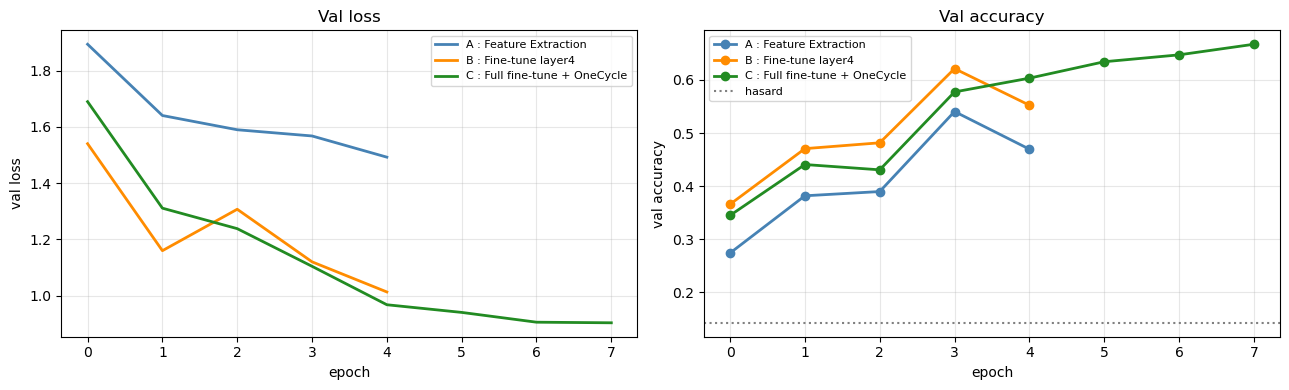

In [11]:
# Courbes d'apprentissage comparées
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["steelblue", "darkorange", "forestgreen"]
for (name, r), c in zip(results.items(), colors):
    axes[0].plot(r["hist"]["val_loss"], color=c, label=name, linewidth=2)
    axes[1].plot(r["hist"]["val_acc"],  color=c, label=name, linewidth=2, marker="o")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val loss")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_title("Val loss")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val accuracy")
axes[1].axhline(1/NUM_CLASSES, color="gray", linestyle=":", label="hasard")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3); axes[1].set_title("Val accuracy")
plt.tight_layout(); plt.show()

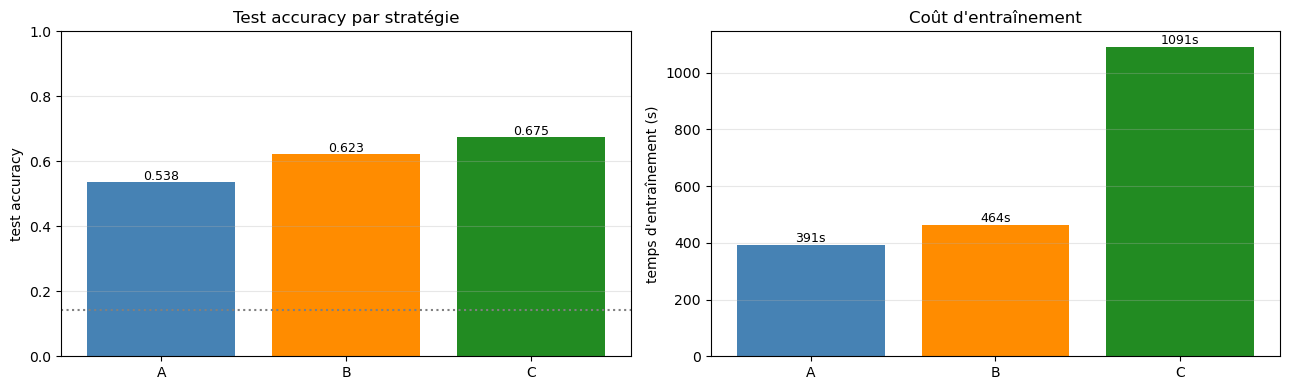

In [12]:
# Barres : test accuracy + temps d'entraînement
names    = list(results.keys())
test_acc = [results[n]["test_acc"] for n in names]
times    = [results[n]["time"]     for n in names]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(len(names)), test_acc, color=colors)
axes[0].set_xticks(range(len(names))); axes[0].set_xticklabels([n.split(":")[0].strip() for n in names])
axes[0].set_ylabel("test accuracy"); axes[0].set_ylim(0.0, 1.0)
axes[0].axhline(1/NUM_CLASSES, color="gray", linestyle=":")
axes[0].set_title("Test accuracy par stratégie")
for i, v in enumerate(test_acc):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(range(len(names)), times, color=colors)
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels([n.split(":")[0].strip() for n in names])
axes[1].set_ylabel("temps d'entraînement (s)")
axes[1].set_title("Coût d'entraînement")
for i, v in enumerate(times):
    axes[1].text(i, v + max(times) * 0.01, f"{v:.0f}s", ha="center", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

**Lecture typique** (dataset médical, *éloigné* d'ImageNet) :
- **Stratégie A** (feature extraction) : entraînement très rapide (~quelques milliers de paramètres), mais l'accuracy plafonne — les features ImageNet (objets naturels) ne décrivent qu'imparfaitement la texture dermatoscopique. C'est attendu pour un domaine éloigné.
- **Stratégie B** (fine-tune `layer4`) : gain net en réadaptant les features de plus haut niveau du backbone à la peau.
- **Stratégie C** (fine-tuning complet + OneCycleLR) : **meilleur résultat**, et l'écart avec B est ici **bien plus marqué** que sur un dataset proche d'ImageNet — c'est précisément sur un domaine distant (médical, satellite) que le fine-tuning profond paie le plus.

Sur ce dataset **déséquilibré**, l'accuracy globale est trompeuse : suivez surtout la **macro-F1** et le rappel des classes rares (*df*, *vasc*).

**À comparer avec le TP 3** : le CNN `SmallVGG` part d'une initialisation aléatoire ; le transfer learning ImageNet converge plus vite et plus haut, même quand le domaine cible diffère sensiblement.

## Partie IX — Évaluation détaillée de la meilleure stratégie

Matrice de confusion, prédictions correctes et erreurs sur le meilleur modèle.

In [13]:
# Sélection du meilleur modèle d'après test_acc
best_name = max(results, key=lambda n: results[n]["test_acc"])
best_model = {"A : Feature Extraction": model_A,
              "B : Fine-tune layer4":   model_B,
              "C : Full fine-tune + OneCycle": model_C}[best_name]
print(f"Meilleur modèle : {best_name}  (test acc = {results[best_name]['test_acc']:.4f})")

@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        probs  = F.softmax(logits, dim=1)
        y_true.append(y.numpy())
        y_pred.append(logits.argmax(1).cpu().numpy())
        y_probs.append(probs.cpu().numpy())
    return (np.concatenate(y_true),
            np.concatenate(y_pred),
            np.concatenate(y_probs))

y_true, y_pred, y_probs = collect_predictions(best_model, test_loader, device)
K = NUM_CLASSES
cm = np.zeros((K, K), dtype=int)
for t, p in zip(y_true, y_pred): cm[t, p] += 1

precision = cm.diagonal() / cm.sum(axis=0).clip(min=1)
recall    = cm.diagonal() / cm.sum(axis=1).clip(min=1)
f1        = 2 * precision * recall / (precision + recall).clip(min=1e-12)

print(f"\n{'Classe':<8} {'Prec':>7} {'Rec':>7} {'F1':>7} {'Support':>9}")
for c, p, r, fs, s in zip(CLASSES_SHORT, precision, recall, f1, cm.sum(axis=1)):
    print(f"{c:<8} {p:>7.3f} {r:>7.3f} {fs:>7.3f} {s:>9}")
print(f"{'macro':<8} {precision.mean():>7.3f} {recall.mean():>7.3f} {f1.mean():>7.3f} {cm.sum():>9}")

Meilleur modèle : C : Full fine-tune + OneCycle  (test acc = 0.6748)

Classe      Prec     Rec      F1   Support
akiec      0.328   0.621   0.429        66
bcc        0.543   0.728   0.622       103
bkl        0.506   0.414   0.455       220
df         0.188   0.565   0.283        23
mel        0.343   0.664   0.453       223
nv         0.952   0.714   0.816      1341
vasc       0.482   0.931   0.635        29
macro      0.478   0.662   0.528      2005


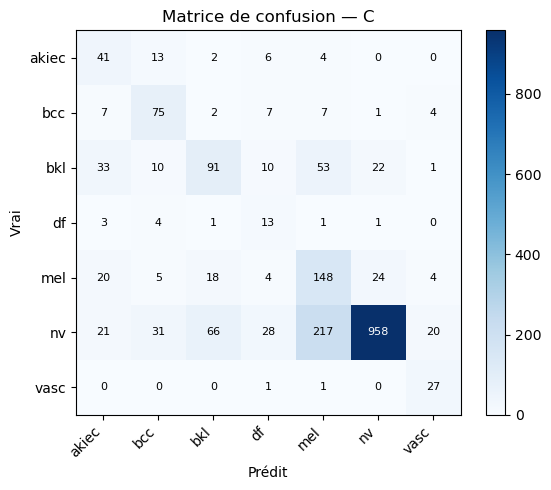

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(CLASSES_SHORT, rotation=45, ha="right"); ax.set_yticklabels(CLASSES_SHORT)
ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai")
ax.set_title(f"Matrice de confusion — {best_name.split(':')[0].strip()}")
for i in range(K):
    for j in range(K):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()

Erreurs sur le test : 652/2005 (32.5%)


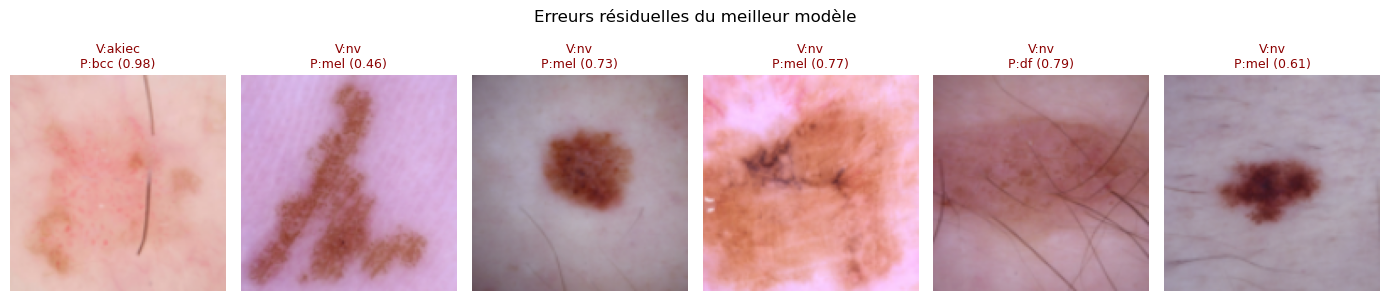

In [15]:
# Visualisation : 6 erreurs typiques
wrong_idx = np.where(y_true != y_pred)[0]
print(f"Erreurs sur le test : {len(wrong_idx)}/{len(y_true)} ({len(wrong_idx)/len(y_true)*100:.1f}%)")

if len(wrong_idx) >= 6:
    rng = np.random.default_rng(SEED)
    sel = rng.choice(wrong_idx, size=6, replace=False)
    fig, axes = plt.subplots(1, 6, figsize=(14, 3))
    for ax, idx in zip(axes, sel):
        img, lab = test_set[int(idx)]
        ax.imshow(aug.denormalize(img).permute(1, 2, 0).numpy())
        ax.set_title(f"V:{CLASSES_SHORT[lab]}\nP:{CLASSES_SHORT[y_pred[idx]]} ({y_probs[idx, y_pred[idx]]:.2f})",
                     fontsize=9, color="darkred")
        ax.axis("off")
    plt.suptitle("Erreurs résiduelles du meilleur modèle", y=1.03)
    plt.tight_layout(); plt.show()
else:
    print("Trop peu d'erreurs pour visualisation.")

## Partie X — Sauvegarde du meilleur modèle

In [16]:
ckpt_path = CKPT_DIR / "resnet18_dermamnist_best.pt"
torch.save({
    "model_state_dict":   best_model.state_dict(),
    "arch":               "resnet18",
    "strategy":           best_name,
    "img_size":           IMG_SIZE,
    "normalize_mean":     IMAGENET_MEAN,
    "normalize_std":      IMAGENET_STD,
    "classes":            CLASSES,
    "classes_short":      CLASSES_SHORT,
    "test_acc":           results[best_name]["test_acc"],
    "trainable_params":   results[best_name]["params"],
}, ckpt_path)
print(f"Modèle sauvegardé : {ckpt_path}")
print(f"Taille : {ckpt_path.stat().st_size / 1024 / 1024:.2f} MB")

Modèle sauvegardé : checkpoints/resnet18_dermamnist_best.pt
Taille : 42.73 MB


## Partie XI — Exercices d'application

### Exercice 1 — Learning rate finder
Implémentez un *LR range test* (Smith, 2017) : entraînez 1 epoch en augmentant exponentiellement le `lr` de $10^{-7}$ à $10$, puis tracez la loss vs lr. Le `max_lr` à utiliser dans OneCycleLR correspond à la valeur juste avant la divergence.

### Exercice 2 — Comparer les backbones
Refaites la stratégie A (feature extraction) avec :
- `torchvision.models.efficientnet_b0`
- `torchvision.models.mobilenet_v3_small`
- `torchvision.models.resnet50`

Tracez accuracy vs nombre de paramètres et discutez le compromis.

### Exercice 3 — Bibliothèque timm
Installez `timm` (PyTorch Image Models) et essayez :
```python
import timm
model = timm.create_model("efficientnetv2_rw_s", pretrained=True, num_classes=7)
```
Comparez à `torchvision.models.efficientnet_b0`.

### Exercice 4 — BatchNorm en mode eval pendant le fine-tuning
Pendant le fine-tuning complet (stratégie C), forcez les BatchNorm en mode `eval()` même pendant `model.train()` (pour figer les statistiques running). Comparez à la baseline. Recette :
```python
def freeze_bn(model):
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters(): p.requires_grad = False
```

### Exercice 5 — Domain shift (test de robustesse)
Construisez une version *altérée* du test en inversant les couleurs (`torchvision.transforms.v2.functional.invert`) ou en virant fortement la teinte, pour simuler un changement de matériel d'acquisition. Évaluez chaque stratégie : laquelle résiste le mieux au *shift* ? Justifiez en lien avec la profondeur de fine-tuning.

### Exercice 6 — Catastrophic forgetting
Reprenez la stratégie C mais avec `lr=1e-2` sur **tout** le modèle (au lieu du lr différentiel). Que se passe-t-il ? Visualisez les courbes d'apprentissage et expliquez le phénomène en termes de *catastrophic forgetting* des features ImageNet.

### Exercice 7 — Gérer le déséquilibre
Comparez la loss pondérée utilisée ici à un `WeightedRandomSampler` dans le `DataLoader`, sur la stratégie C. Mesurez l'effet sur la **macro-F1** et le rappel des classes rares (*df*, *vasc*).

---

## Synthèse — API PyTorch Transfer Learning

| Concept | API PyTorch |
|---------|-------------|
| Modèles pré-entraînés (zoo torchvision) | `torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)` |
| Zoo étendu (centaines de modèles) | `timm.create_model("<name>", pretrained=True, num_classes=N)` |
| Geler des paramètres | `for p in module.parameters(): p.requires_grad = False` |
| Compter params entraînables | `sum(p.numel() for p in m.parameters() if p.requires_grad)` |
| Remplacer la tête | `model.fc = nn.Linear(in_features, num_classes)` |
| LR différentiel | `optim.Adam([{"params": ..., "lr": ...}, ...])` |
| Scheduler warm-up + cosinus | `optim.lr_scheduler.OneCycleLR(opt, max_lr=..., total_steps=...)` |
| Loss pondérée (déséquilibre) | `nn.CrossEntropyLoss(weight=class_weights)` |
| Statistiques ImageNet | `mean=(0.485, 0.456, 0.406)`, `std=(0.229, 0.224, 0.225)` |
| Mode eval (Dropout/BN) | `model.eval()` + `with torch.no_grad():` |
| Mixed precision | `torch.cuda.amp.autocast()`, `torch.cuda.amp.GradScaler()` |

---

**Prochain TP** (Module 2 suite) : `05_rnn_lstm_series_temporelles.ipynb` — LSTM/GRU/BiLSTM pour prévision et détection d'anomalies sur séries temporelles industrielles.